In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime 

In [2]:
df=pd.read_csv(r'C:\Users\RISHABH SINGH\Desktop\INTERNSHALA\PROJECT FILES\PYTHON\jp_morgan.csv')


In [3]:
df.describe



<bound method NDFrame.describe of      Transaction ID Customer ID Account ID Account Type Transaction Type  \
0                17    CUST9525   ACC10117         Loan         Transfer   
1               140    CUST9843   ACC10996      Current       Withdrawal   
2                63    CUST4373   ACC10996       Credit          Deposit   
3               106    CUST1547   ACC10996       Credit          Deposit   
4                44    CUST3725   ACC10996       Credit         Transfer   
..              ...         ...        ...          ...              ...   
795              47    CUST8765   ACC99549      Savings          Deposit   
796              40    CUST8155   ACC99549       Credit          Payment   
797               3    CUST5609   ACC99549      Savings       Withdrawal   
798              92    CUST3131   ACC99549       Credit          Payment   
799             111    CUST1189   ACC99549         Loan       Withdrawal   

             Product    Firm   Region    Manager Tran

In [6]:
df.isnull().any()

Transaction ID        False
Customer ID           False
Account ID            False
Account Type          False
Transaction Type      False
Product               False
Firm                  False
Region                False
Manager               False
Transaction Date      False
Transaction Amount    False
Account Balance       False
Risk Score            False
Credit Rating         False
Tenure Months         False
dtype: bool

In [7]:
df.dtypes

Transaction ID          int64
Customer ID            object
Account ID             object
Account Type           object
Transaction Type       object
Product                object
Firm                   object
Region                 object
Manager                object
Transaction Date       object
Transaction Amount    float64
Account Balance       float64
Risk Score            float64
Credit Rating           int64
Tenure Months           int64
dtype: object

In [17]:
#As you can notice the column names don't have spaces between words, so I will use a regular expression
#to insert a space between a lowercase and uppercase letter in each column name.
import re

df.columns = [
    re.sub(r'([a-z])([A-Z])', r'\1 \2', col)
    for col in df.columns
]
print(df)
df.to_csv(r'C:\Users\RISHABH SINGH\Desktop\INTERNSHALA\PROJECT FILES\PYTHON\jp_morgan.csv',index=False)

     Transaction ID Customer ID Account ID Account Type Transaction Type  \
0                 3    CUST2412   ACC80131         Loan       Withdrawal   
1                32    CUST1467   ACC74631      Current       Withdrawal   
2                 9    CUST2699   ACC39482         Loan       Withdrawal   
3                42    CUST9535   ACC82947      Current       Withdrawal   
4               166    CUST7459   ACC39500       Credit          Payment   
..              ...         ...        ...          ...              ...   
795             157    CUST4346   ACC48303      Savings          Payment   
796              46    CUST7120   ACC42710      Current         Transfer   
797              79    CUST5574   ACC89098      Current       Withdrawal   
798             189    CUST9754   ACC86784         Loan          Deposit   
799             175    CUST3725   ACC34119         Loan       Withdrawal   

             Product    Firm Region    Manager Transaction Date  \
0      Personal Loan

In [8]:
# Task 1--->>>Data cleaning and formatting 

#1.Removing non-numeric from financial fields 

financial_cols = ['Transaction Amount','Account Balance','Risk Score','Credit Rating','Tenure Months']
for col in financial_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')
    
df



,Transaction ID,Customer ID,Account ID,Account Type,Transaction Type,Product,Firm,Region,Manager,Transaction Date,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.690570,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.199330,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.484830,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.796970,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.973550,113405.32820,0.380675,411,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,157,CUST4346,ACC48303,Savings,Payment,Mutual Fund,Firm E,North,Manager 3,09-04-2023,105645.967500,13571.39382,0.507578,815,8
796,46,CUST7120,ACC42710,Current,Transfer,Mutual Fund,Firm B,North,Manager 4,22-03-2024,113961.373300,90617.07646,-0.037634,338,203
797,79,CUST5574,ACC89098,Current,Withdrawal,Savings Account,Firm D,North,Manager 1,22-10-2023,-6892.749584,71282.75779,0.143038,818,200
798,189,CUST9754,ACC86784,Loan,Deposit,Mutual Fund,Firm B,West,Manager 4,28-11-2023,45433.510640,103798.75240,0.245964,528,239


In [9]:
#2.Rounding off the financial columns values upto 2 decimal places  
df[financial_cols]=df[financial_cols].round(2)
df[financial_cols]

,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months
0,33759.69,126486.41,0.23,611,89
1,69319.20,24834.76,0.34,817,174
2,42831.48,123007.44,0.57,332,31
3,70903.80,73073.64,0.57,626,92
4,21948.97,113405.33,0.38,411,13
...,...,...,...,...,...
795,105645.97,13571.39,0.51,815,8
796,113961.37,90617.08,-0.04,338,203
797,-6892.75,71282.76,0.14,818,200
798,45433.51,103798.75,0.25,528,239


In [10]:
#3.Drop rows with NaN in financial cols
df.dropna(subset=financial_cols)
df

,Transaction ID,Customer ID,Account ID,Account Type,Transaction Type,Product,Firm,Region,Manager,Transaction Date,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69,126486.41,0.23,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.20,24834.76,0.34,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48,123007.44,0.57,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.80,73073.64,0.57,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97,113405.33,0.38,411,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,157,CUST4346,ACC48303,Savings,Payment,Mutual Fund,Firm E,North,Manager 3,09-04-2023,105645.97,13571.39,0.51,815,8
796,46,CUST7120,ACC42710,Current,Transfer,Mutual Fund,Firm B,North,Manager 4,22-03-2024,113961.37,90617.08,-0.04,338,203
797,79,CUST5574,ACC89098,Current,Withdrawal,Savings Account,Firm D,North,Manager 1,22-10-2023,-6892.75,71282.76,0.14,818,200
798,189,CUST9754,ACC86784,Loan,Deposit,Mutual Fund,Firm B,West,Manager 4,28-11-2023,45433.51,103798.75,0.25,528,239


In [11]:
df.dropna()

,Transaction ID,Customer ID,Account ID,Account Type,Transaction Type,Product,Firm,Region,Manager,Transaction Date,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69,126486.41,0.23,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.20,24834.76,0.34,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48,123007.44,0.57,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.80,73073.64,0.57,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97,113405.33,0.38,411,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,157,CUST4346,ACC48303,Savings,Payment,Mutual Fund,Firm E,North,Manager 3,09-04-2023,105645.97,13571.39,0.51,815,8
796,46,CUST7120,ACC42710,Current,Transfer,Mutual Fund,Firm B,North,Manager 4,22-03-2024,113961.37,90617.08,-0.04,338,203
797,79,CUST5574,ACC89098,Current,Withdrawal,Savings Account,Firm D,North,Manager 1,22-10-2023,-6892.75,71282.76,0.14,818,200
798,189,CUST9754,ACC86784,Loan,Deposit,Mutual Fund,Firm B,West,Manager 4,28-11-2023,45433.51,103798.75,0.25,528,239


In [12]:
#4 Format date column
df['Transaction Date']=df['Transaction Date'].apply(pd.to_datetime,format='%d-%m-%Y',errors='coerce')
df['Transaction Date'].dropna().reset_index(drop=True)

0     2023-08-06
1     2023-11-08
2     2024-05-15
3     2023-04-30
4     2023-02-16
         ...    
795   2023-04-09
796   2024-03-22
797   2023-10-22
798   2023-11-28
799   2023-04-23
Name: Transaction Date, Length: 800, dtype: datetime64[ns]

In [13]:
#5 Standardize categories 
category_cols=['Account Type','Transaction Type','Product','Firm','Region','Manager']
for col in category_cols:
    df[col]=df[col].str.strip().str.title()

In [14]:
df[category_cols]

,Account Type,Transaction Type,Product,Firm,Region,Manager
0,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3
1,Current,Withdrawal,Home Loan,Firm D,North,Manager 2
2,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4
3,Current,Withdrawal,Home Loan,Firm A,South,Manager 4
4,Credit,Payment,Home Loan,Firm D,South,Manager 4
...,...,...,...,...,...,...
795,Savings,Payment,Mutual Fund,Firm E,North,Manager 3
796,Current,Transfer,Mutual Fund,Firm B,North,Manager 4
797,Current,Withdrawal,Savings Account,Firm D,North,Manager 1
798,Loan,Deposit,Mutual Fund,Firm B,West,Manager 4


In [61]:
#6 Repalced 'Withdrawal' with 'Withdrawl'
df['Transaction Type'].replace("Withdrawl","Withdrawal",inplace=True) 

C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_6936\1905787859.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transaction Type'].replace("Withdrawl","Withdrawal",inplace=True)


In [16]:
#7 To Standardise Transaction Amount Signs: 
#Assume Deposit/Transfer as Positive(inflow)
#Withdrawl/Payment as Negative(outflow) 

def standardize_amount(row):
    if row ['Transaction Type'] in ['Withdrawl','Payment']:
        return -abs(row['Transaction Amount'])
    else: #Deposit,Transfer  
        return abs(row['Transaction Amount'])

df['Transaction Amount']=df.apply(standardize_amount,axis=1)
df

,Transaction ID,Customer ID,Account ID,Account Type,Transaction Type,Product,Firm,Region,Manager,Transaction Date,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months
0,3,CUST2412,ACC80131,Loan,Withdrawl,Personal Loan,Firm C,West,Manager 3,2023-08-06,-33759.69,126486.41,0.23,611,89
1,32,CUST1467,ACC74631,Current,Withdrawl,Home Loan,Firm D,North,Manager 2,2023-11-08,-69319.20,24834.76,0.34,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawl,Credit Card,Firm D,West,Manager 4,2024-05-15,-42831.48,123007.44,0.57,332,31
3,42,CUST9535,ACC82947,Current,Withdrawl,Home Loan,Firm A,South,Manager 4,2023-04-30,-70903.80,73073.64,0.57,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,2023-02-16,-21948.97,113405.33,0.38,411,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,157,CUST4346,ACC48303,Savings,Payment,Mutual Fund,Firm E,North,Manager 3,2023-04-09,-105645.97,13571.39,0.51,815,8
796,46,CUST7120,ACC42710,Current,Transfer,Mutual Fund,Firm B,North,Manager 4,2024-03-22,113961.37,90617.08,-0.04,338,203
797,79,CUST5574,ACC89098,Current,Withdrawl,Savings Account,Firm D,North,Manager 1,2023-10-22,-6892.75,71282.76,0.14,818,200
798,189,CUST9754,ACC86784,Loan,Deposit,Mutual Fund,Firm B,West,Manager 4,2023-11-28,45433.51,103798.75,0.25,528,239


In [17]:
#8 Sort by date for each account  
df=df.sort_values(['Account ID','Transaction Date'])

In [51]:
df.to_csv(r'C:\Users\RISHABH SINGH\Desktop\INTERNSHALA\PROJECT FILES\PYTHON\jp_morgan.csv',index=False)

In [52]:
df

,Transaction ID,Customer ID,Account ID,Account Type,Transaction Type,Product,Firm,Region,Manager,Transaction Date,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months,Month,Year,Activity Level,Abs Amount
0,17,CUST9525,ACC10117,Loan,Transfer,Savings Account,Firm C,North,Manager 1,2023-11-25,56317.92,90780.26,0.28,769,137,2023-11,2023,Low,56317.92
1,140,CUST9843,ACC10996,Current,Withdrawal,Credit Card,Firm D,East,Manager 4,2023-01-21,-59601.06,42962.45,0.48,363,185,2023-01,2023,Low,59601.06
2,63,CUST4373,ACC10996,Credit,Deposit,Savings Account,Firm B,South,Manager 1,2023-07-01,81608.80,67810.12,0.51,694,103,2023-07,2023,Low,81608.80
3,106,CUST1547,ACC10996,Credit,Deposit,Personal Loan,Firm C,North,Manager 4,2023-10-19,92323.66,39827.55,0.67,768,198,2023-10,2023,Low,92323.66
4,44,CUST3725,ACC10996,Credit,Transfer,Savings Account,Firm D,South,Manager 4,2023-11-06,9775.98,105586.15,0.18,383,172,2023-11,2023,Low,9775.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,47,CUST8765,ACC99549,Savings,Deposit,Credit Card,Firm B,West,Manager 2,2023-03-18,2521.85,91557.36,0.34,747,110,2023-03,2023,Medium,2521.85
796,40,CUST8155,ACC99549,Credit,Payment,Personal Loan,Firm A,East,Manager 1,2023-04-03,-103449.41,113021.99,0.09,380,190,2023-04,2023,Medium,103449.41
797,3,CUST5609,ACC99549,Savings,Withdrawal,Personal Loan,Firm C,West,Manager 3,2023-11-21,-79849.03,145083.85,0.43,593,164,2023-11,2023,Medium,79849.03
798,92,CUST3131,ACC99549,Credit,Payment,Personal Loan,Firm A,Central,Manager 1,2023-11-25,-85584.77,103399.06,0.23,767,100,2023-11,2023,Medium,85584.77


In [ ]:
#Task 2--->>>> Descriptive Transactional Analysis
#1-Sub-Task
## Add month and year
df['Month'] = df['Transaction Date'].dt.to_period('M')
df['Year'] = df['Transaction Date'].dt.to_period('Y')

# Monthly summaries
monthly_summary = df.groupby('Month').agg(
    total_credits=('Transaction Amount', lambda x: x[x > 0].sum()),
    total_debits=('Transaction Amount', lambda x: x[x < 0].sum()),
    net_volume=('Transaction Amount', 'sum')
).reset_index()

# Yearly summaries
yearly_summary = df.groupby('Year').agg(
    total_credits=('Transaction Amount', lambda x: x[x > 0].sum()),
    total_debits=('Transaction Amount', lambda x: x[x < 0].sum()),
    net_volume=('Transaction Amount', 'sum')
).reset_index()
print(f"Monthly_Summary:{monthly_summary}\n\n Yearly_Summary:{yearly_summary}")

Monthly_Summary:      Month  total_credits  total_debits  net_volume
0   2023-01     1105532.22   -1708184.46  -602652.24
1   2023-02     1431298.77   -1336328.18    94970.59
2   2023-03     1007830.73   -1520971.73  -513141.00
3   2023-04     1142478.23   -1612825.24  -470347.01
4   2023-05     1576453.10   -1053812.50   522640.60
5   2023-06     1487870.62    -753026.34   734844.28
6   2023-07     1381409.73   -1097056.77   284352.96
7   2023-08     1308379.45    -864172.38   444207.07
8   2023-09      998754.98   -1154629.99  -155875.01
9   2023-10     1444629.88   -1736580.15  -291950.27
10  2023-11     1284115.98   -1705052.63  -420936.65
11  2023-12      583231.70    -783122.03  -199890.33
12  2024-01      489239.40    -866971.95  -377732.55
13  2024-02      909538.71   -1066947.78  -157409.07
14  2024-03     1800044.84   -1463194.30   336850.54
15  2024-04      659189.81   -1202218.41  -543028.60
16  2024-05      542157.50   -1141934.77  -599777.27
17  2024-06      832824.32    

In [67]:
monthly_summary

,Month,total_credits,total_debits,net_volume
0,2023-01,1105532.22,-1708184.46,-602652.24
1,2023-02,1431298.77,-1336328.18,94970.59
2,2023-03,1007830.73,-1520971.73,-513141.00
3,2023-04,1142478.23,-1612825.24,-470347.01
4,2023-05,1576453.10,-1053812.50,522640.60
5,2023-06,1487870.62,-753026.34,734844.28
6,2023-07,1381409.73,-1097056.77,284352.96
7,2023-08,1308379.45,-864172.38,444207.07
8,2023-09,998754.98,-1154629.99,-155875.01
9,2023-10,1444629.88,-1736580.15,-291950.27


In [64]:
df['Transaction Date']=pd.to_datetime(df['Transaction Date'],errors='coerce')

In [65]:
df

,Transaction ID,Customer ID,Account ID,Account Type,Transaction Type,Product,Firm,Region,Manager,Transaction Date,Transaction Amount,Account Balance,Risk Score,Credit Rating,Tenure Months,Month,Year
0,17,CUST9525,ACC10117,Loan,Transfer,Savings Account,Firm C,North,Manager 1,2023-11-25,56317.92,90780.26,0.28,769,137,2023-11,2023
1,140,CUST9843,ACC10996,Current,Withdrawal,Credit Card,Firm D,East,Manager 4,2023-01-21,-59601.06,42962.45,0.48,363,185,2023-01,2023
2,63,CUST4373,ACC10996,Credit,Deposit,Savings Account,Firm B,South,Manager 1,2023-07-01,81608.80,67810.12,0.51,694,103,2023-07,2023
3,106,CUST1547,ACC10996,Credit,Deposit,Personal Loan,Firm C,North,Manager 4,2023-10-19,92323.66,39827.55,0.67,768,198,2023-10,2023
4,44,CUST3725,ACC10996,Credit,Transfer,Savings Account,Firm D,South,Manager 4,2023-11-06,9775.98,105586.15,0.18,383,172,2023-11,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,47,CUST8765,ACC99549,Savings,Deposit,Credit Card,Firm B,West,Manager 2,2023-03-18,2521.85,91557.36,0.34,747,110,2023-03,2023
796,40,CUST8155,ACC99549,Credit,Payment,Personal Loan,Firm A,East,Manager 1,2023-04-03,-103449.41,113021.99,0.09,380,190,2023-04,2023
797,3,CUST5609,ACC99549,Savings,Withdrawal,Personal Loan,Firm C,West,Manager 3,2023-11-21,-79849.03,145083.85,0.43,593,164,2023-11,2023
798,92,CUST3131,ACC99549,Credit,Payment,Personal Loan,Firm A,Central,Manager 1,2023-11-25,-85584.77,103399.06,0.23,767,100,2023-11,2023


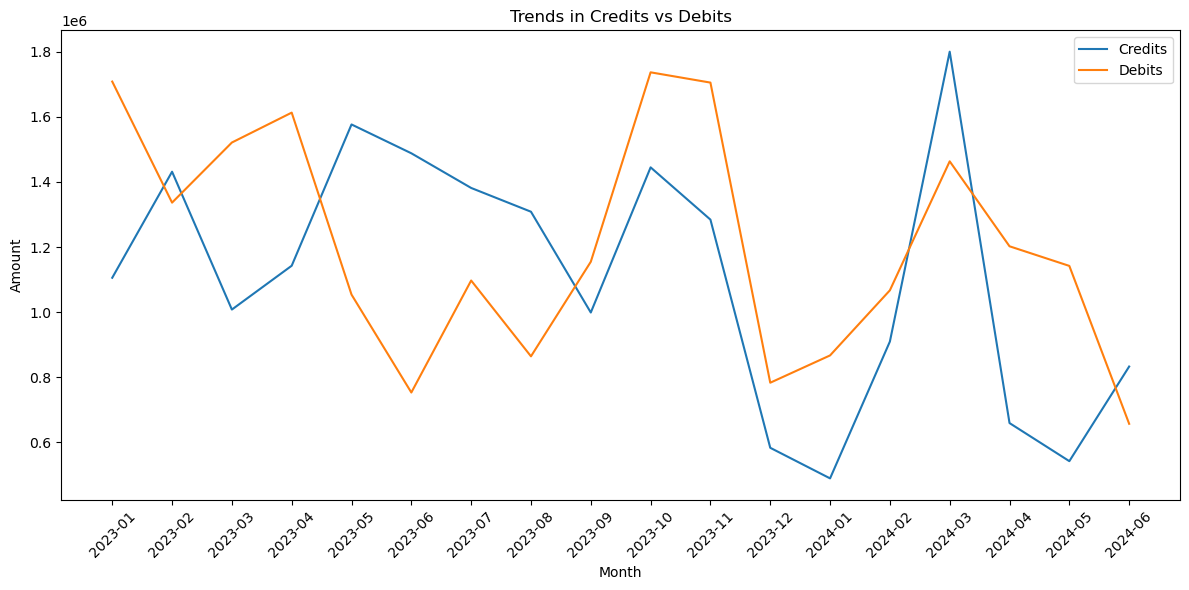

In [31]:
#Sub-Task-2 
# Plot trends
plt.figure(figsize=(12,6))
plt.plot(monthly_summary['Month'].astype(str), monthly_summary['total_credits'], label='Credits')
plt.plot(monthly_summary['Month'].astype(str), monthly_summary['total_debits'].abs(), label='Debits')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Trends in Credits vs Debits')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('trends.png')
plt.show()

In [38]:
#Sub-Task-3 
# Top and bottom accounts based on net inflow
account_net = df.groupby('Account ID')['Transaction Amount'].sum().sort_values(ascending=False)
top_accounts = account_net.head(10)
bottom_accounts = account_net.tail(10)
print(f"Top Accounts Based on Net-Inflow:{top_accounts}\n Bottom Accounts Based on Net-Inflow:{bottom_accounts}")

Top Accounts Based on Net-Inflow:Account ID
ACC42710    321519.71
ACC29396    307426.23
ACC13357    303391.46
ACC32627    281479.03
ACC75767    254145.45
ACC96868    236018.74
ACC22036    234000.77
ACC92104    231854.02
ACC54589    225122.49
ACC67713    203189.36
Name: Transaction Amount, dtype: float64
 Bottom Accounts Based on Net-Inflow:Account ID
ACC67701   -195706.10
ACC55331   -209331.98
ACC88252   -214240.29
ACC58078   -217211.70
ACC53865   -230206.15
ACC61926   -231492.59
ACC29477   -293945.06
ACC35419   -296560.67
ACC18140   -298337.52
ACC99549   -334511.55
Name: Transaction Amount, dtype: float64


In [103]:
#Sub-Task-4 
# Flag dormant accounts: gap of 2 months or more
def is_dormant(group):
    group = group.sort_values('Transaction Date')
    if len(group) < 2:
        return False
    diffs = group['Transaction Date'].diff().dt.days[1:]
    return (diffs > 60).any()



In [112]:
dormant_accounts = df.groupby('Account ID').apply(is_dormant)
print(dormant_accounts.value_counts())
print(round(dormant_accounts.value_counts(normalize=True)*100,2))

True     164
False     30
Name: count, dtype: int64
True     84.54
False    15.46
Name: proportion, dtype: float64


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_6936\1838608394.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dormant_accounts = df.groupby('Account ID').apply(is_dormant)


In [40]:
# Task 3: Customer Profile Building
# Sub-Task-1-Transaction frequency per account
freq = df.groupby('Account ID')['Transaction ID'].count()

# Rubric for activity levels
def activity_level(count):
    if count > 10:
        return 'High'
    elif count >= 5:
        return 'Medium'
    else:
        return 'Low'

df['Activity Level'] = df['Account ID'].map(freq).map(activity_level)
print(df['Activity Level'])


0         Low
1         Low
2         Low
3         Low
4         Low
        ...  
795    Medium
796    Medium
797    Medium
798    Medium
799    Medium
Name: Activity Level, Length: 800, dtype: object


In [35]:
#Sub-Task-2-Segment by average balance and txn volume
avg_balance = round(df.groupby('Account ID')['Account Balance'].mean(),2)
df['Abs Amount'] = df['Transaction Amount'].abs()
txn_volume = df.groupby('Account ID')['Abs Amount'].sum()

segments = pd.DataFrame({'Avg Balance': avg_balance, 'Txn Volume': txn_volume})
print(segments)


            Avg Balance  Txn Volume
Account ID                         
ACC10117       90780.26    56317.92
ACC10996       64046.57   243309.50
ACC11062       62784.10   265928.57
ACC11188       80558.92   116557.96
ACC11285       95745.55   373189.54
...                 ...         ...
ACC97225       80994.27   160001.05
ACC97411       61783.63   310826.63
ACC99117       80478.45   436184.68
ACC99409       32962.94   169048.80
ACC99549      102738.12   339555.25

[194 rows x 2 columns]


In [36]:
#Sub-Task-3-Quartiles for segmentation
balance_quartiles = avg_balance.quantile([0.33, 0.66])
volume_quartiles = txn_volume.quantile([0.33, 0.66])

def balance_segment(val):
    if val < balance_quartiles[0.33]:
        return 'Low Balance'
    elif val < balance_quartiles[0.66]:
        return 'Medium Balance'
    else:
        return 'High Balance'

def volume_segment(val):
    if val < volume_quartiles[0.33]:
        return 'Low Volume'
    elif val < volume_quartiles[0.66]:
        return 'Medium Volume'
    else:
        return 'High Volume'

segments['Balance Segment'] = segments['Avg Balance'].apply(balance_segment)
segments['Volume Segment'] = segments['Txn Volume'].apply(volume_segment)

segments


,Avg Balance,Txn Volume,Balance Segment,Volume Segment
Account ID,,,,
ACC10117,90780.26,56317.92,High Balance,Low Volume
ACC10996,64046.57,243309.50,Low Balance,Medium Volume
ACC11062,62784.10,265928.57,Low Balance,High Volume
ACC11188,80558.92,116557.96,Medium Balance,Low Volume
ACC11285,95745.55,373189.54,High Balance,High Volume
...,...,...,...,...
ACC97225,80994.27,160001.05,Medium Balance,Medium Volume
ACC97411,61783.63,310826.63,Low Balance,High Volume
ACC99117,80478.45,436184.68,Medium Balance,High Volume


In [41]:
#Sub-Task-4-Profiles
high_net = account_net[account_net > account_net.quantile(0.75)].index.tolist()
high_freq_low_bal = freq[(freq > freq.quantile(0.75)) & (avg_balance < avg_balance.quantile(0.25))].index.tolist()
neg_bal = avg_balance[avg_balance <= 0].index.tolist()
print(f"High Net-Worth:{len(high_net)}\nRed Flag:{len(high_freq_low_bal)}\nOverdrawn:{len(neg_bal)}")

High Net-Worth:49
Red Flag:7
Overdrawn:0


In [ ]:
# Task 4: Financial Risk Identification 

#Sub-Task-1-Frequent large withdrawals
avg_debit = df[df['Transaction Amount'] < 0]['Transaction Amount'].abs().mean()
large_withdrawals = df[(df['Transaction Amount'] < 0) & (df['Transaction Amount'].abs() > 2 * avg_debit)]
freq_large = large_withdrawals.groupby('Account ID').size()
risky_withdraw = freq_large[freq_large > 3].index.tolist()
print(f"{freq_large}\n{risky_withdraw}")


Account ID
ACC15671    1
ACC29477    1
ACC40939    1
ACC40952    1
ACC41829    1
ACC45907    1
ACC48303    1
ACC55331    2
ACC62809    1
ACC70460    1
ACC81631    1
ACC95164    1
ACC99117    1
ACC99549    1
dtype: int64
[]


In [13]:
#Sub-Task-2-Balance volatility
cv_balance = df.groupby('Account ID')['Account Balance'].std() / df.groupby('Account ID')['Account Balance'].mean().abs()
high_vol = cv_balance[cv_balance > 1].index.tolist()
print(f"{cv_balance}\n{high_vol}")

Account ID
ACC10117         NaN
ACC10996    0.474511
ACC11062    0.598852
ACC11188    0.419343
ACC11285    0.440116
              ...   
ACC97225    0.414728
ACC97411    0.561893
ACC99117    0.358078
ACC99409    0.915250
ACC99549    0.299911
Name: Account Balance, Length: 194, dtype: float64
['ACC39529', 'ACC49774', 'ACC61827', 'ACC78589']


In [17]:
#Sub-Task-3-Anomalies using z-score
def detect_anomalies(group):
    if len(group) < 2:
        return pd.Series(False, index=group.index)
    z = np.abs(stats.zscore(group['Transaction Amount']))
    return pd.Series(z>3,index=group.index)

anomalies = df.groupby('Account ID').apply(detect_anomalies)
anomaly_accounts = anomalies[anomalies].index.get_level_values('Account ID').unique().tolist()
print(f"{anomalies}\n{anomaly_accounts}")

Account ID     
ACC10117    0      False
ACC10996    1      False
            2      False
            3      False
            4      False
                   ...  
ACC99549    795    False
            796    False
            797    False
            798    False
            799    False
Length: 800, dtype: bool
[]


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_21804\3989636279.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  anomalies = df.groupby('Account ID').apply(detect_anomalies)


In [19]:
#Sub-Task-4-Irregular behavior
irregular = df[(df['Risk Score'] > 0.8) | (df['Credit Rating'] < 400)]['Account ID'].unique().tolist()
print(irregular)

['ACC10996', 'ACC11062', 'ACC11188', 'ACC11285', 'ACC11837', 'ACC12182', 'ACC12334', 'ACC13357', 'ACC15228', 'ACC15671', 'ACC15925', 'ACC16241', 'ACC18140', 'ACC18177', 'ACC19178', 'ACC20297', 'ACC21264', 'ACC21429', 'ACC21719', 'ACC21878', 'ACC22036', 'ACC23736', 'ACC23985', 'ACC24070', 'ACC24508', 'ACC24981', 'ACC25132', 'ACC25811', 'ACC26026', 'ACC26940', 'ACC26956', 'ACC26973', 'ACC28154', 'ACC28295', 'ACC28612', 'ACC29007', 'ACC29396', 'ACC29477', 'ACC29646', 'ACC30787', 'ACC30852', 'ACC32212', 'ACC32627', 'ACC32890', 'ACC33287', 'ACC34119', 'ACC34431', 'ACC34568', 'ACC34821', 'ACC35163', 'ACC35419', 'ACC37688', 'ACC38559', 'ACC39482', 'ACC39544', 'ACC40939', 'ACC40952', 'ACC41829', 'ACC42710', 'ACC42903', 'ACC43309', 'ACC45101', 'ACC45907', 'ACC45968', 'ACC46655', 'ACC46953', 'ACC48303', 'ACC48501', 'ACC49180', 'ACC49395', 'ACC49422', 'ACC49774', 'ACC50817', 'ACC51009', 'ACC51593', 'ACC52131', 'ACC52650', 'ACC53466', 'ACC53865', 'ACC54589', 'ACC55331', 'ACC55729', 'ACC57516', 'AC

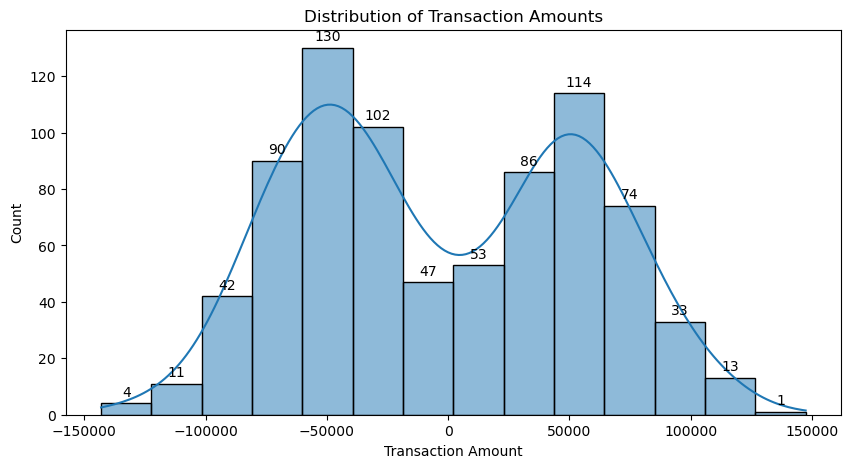

In [12]:
#Task 5: Visualisation
# Distribution of Transaction Amounts
plt.figure(figsize=(10,5))
Dist_Txn_Amn=sns.histplot(df['Transaction Amount'], kde=True)
for container in Dist_Txn_Amn.containers:
    Dist_Txn_Amn.bar_label(container,padding=3)
plt.title('Distribution of Transaction Amounts')
plt.savefig('txn_dist.png')

#As we can see the graph is bimodal,means it has two specific humps on -50k and 50k

#This graph suggests a very balanced financial activity where the volume of money going out (the left side) 
# is mirrored almost exactly by the volume of money coming in (the right side).





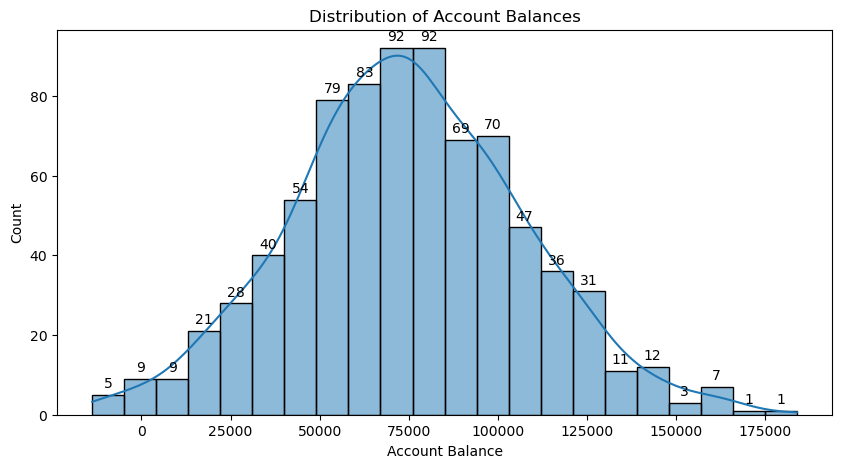

In [11]:
# Balance distribution
plt.figure(figsize=(10,5))
Dist=sns.histplot(df['Account Balance'], kde=True)
for container in Dist.containers:
    Dist.bar_label(container,padding=3)
plt.title('Distribution of Account Balances')
plt.savefig('bal_dist.png')

#Since the data is normally distributed, it is well-suited for standard statistical modeling. 

#It suggests a very stable and consistent user base in terms of wealth distribution.

#Almost 90 accounts have maintained the median balance of $70k-$75k 

#Significant growth in the account balances of those who falls between $25k-$65k 

#As the tail in the right side skewed with bars shorter means we have few individuals who have high  Net-Worth. 


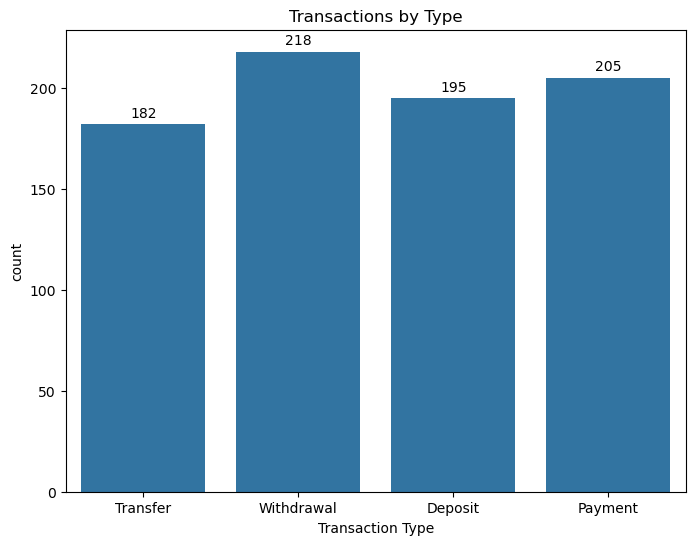

In [ ]:
# Transactions by type
plt.figure(figsize=(8,6))
Txn=sns.countplot(data=df, x='Transaction Type')
for container in Txn.containers:
    Txn.bar_label(container,padding=3)
plt.title('Transactions by Type')
plt.savefig('txn_type.png')

#Withdrawal is the highest among the transaction types 

#Total 'outflows' is slightly higher than Total 'inflows'.

#All categories are above 150 indicates a very active dataset with a healthy mix of different banking activities.

#All of the above it is a balanced dataset for modeling.

In [16]:
plt.show(Txn.containers)

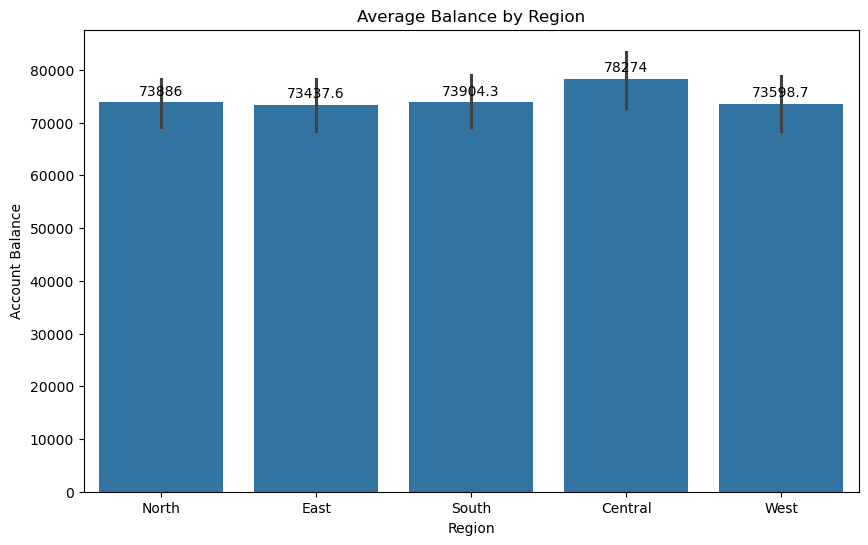

In [ ]:
# Average balance by region
plt.figure(figsize=(10,6))
Avg_Bal=sns.barplot(data=df, x='Region', y='Account Balance', estimator='mean')
for container in Avg_Bal.containers:
    Avg_Bal.bar_label(container,padding=3)
plt.title('Average Balance by Region')
plt.savefig('bal_region.png')

#Central Region has the highest average balance 

#Customer wealth is distributed very evenly across most of the territory,with the exception of the Central hub.

#The error bar(vertical black line) also known as confidence interval(usually 95%) is higher in central region. 

#Error bar shows that 'North' and 'South' regions have stable account balances,while central region have uncertainty. 




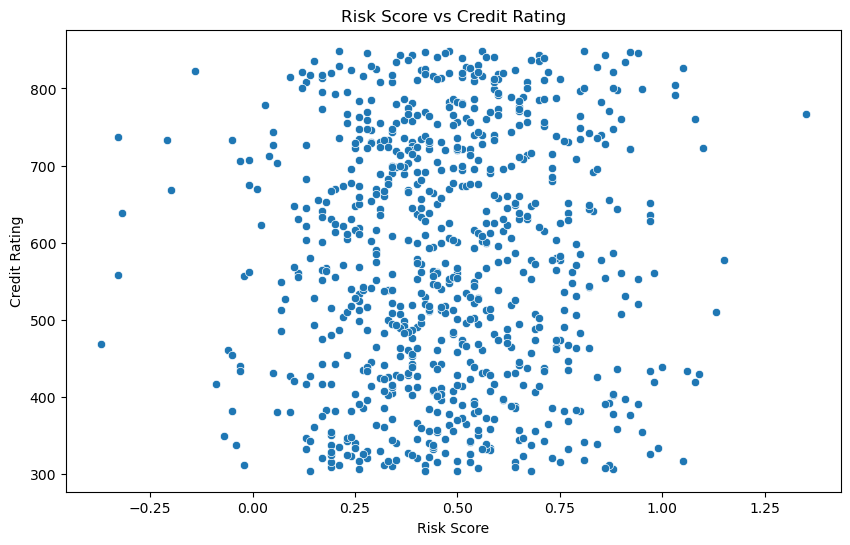

In [ ]:
# Risk score vs Credit rating
plt.figure(figsize=(10,6))
Rs_vs_Cr=sns.scatterplot(data=df, x='Risk Score', y='Credit Rating')
plt.title('Risk Score vs Credit Rating')
plt.savefig('risk_credit.png')

#There is very low to no linear correlation. 

#The middle clustered thick cloud shows the risk score of 0.50 has 600 credit rating. 

#The dots are scattered in a "cloud" or "blob" shape. 

#This suggests that a person’s Risk Score in this dataset is not a direct predictor of their Credit Rating.

In [ ]:
# Task 6: Hypothesis Testing

#Sub-Task-1-Hypothesis testing based on volume of accounts vs balance of accounts  

high_vol_accounts = segments[segments['Volume Segment'] == 'High Volume'].index
low_vol_accounts = segments[segments['Volume Segment'] == 'Low Volume'].index

high_bal = df[df['Account ID'].isin(high_vol_accounts)]['Account Balance']
low_bal = df[df['Account ID'].isin(low_vol_accounts)]['Account Balance']

t_stat, p_val = stats.ttest_ind(high_bal, low_bal, equal_var=False)

print(t_stat,p_val)

#1.t_stat value is negative, it means the first group (high_bal) has a 
'''slightly lower average balance than the second group (low_bal).'''

#2.(-0.457) is a very small value.
'''This value rules out that there is no meaningful differnece between two groups.'''

#3.The probability value must be <0.05 to be statistically significant but we have much larger value: 
'''Which is just a random chance or noise''' 

#4.There is no meaningful difference between the account balances of "High Volume" and "Low Volume" users:
'''We cannot assume that a customer who trades frequently (High Volume) is wealthier than one who trades rarely (Low Volume)'''

#5.The account balances of two groups are effectively the same.

-0.45713315074655375 0.6479635676412394


In [ ]:
#Sub-Task-2-Hypothesis testing based on segmentation 

medium_act = df[df['Activity Level'] == 'Medium']['Account Balance']
low_act = df[df['Activity Level'] == 'Low']['Account Balance']

t_stat2, p_val2 = stats.ttest_ind(medium_act, low_act, equal_var=False)

print(t_stat2,p_val2)

#1.T-Statistic:(This value is very close to zero)
'''It indicates that the average account balance for "Medium" activity users
 is nearly identical to that of "Low" activity users.'''  

#2.P-Value (This is the most important number here) 0.836>0.05 Since the result is not statistically significant. 

#3.There is no evidence in the current dataset to suggest that 
'''The "Medium" activity level leads to a different "Account Balance" than "Low" activity level. 
The difference we are seeing is likely due to random chance (noise).''' 

#4.In this specific dataset:
'''how often someone uses their account simply might not correlate with how much money they keep in it.'''


0.206764850102021 0.8362550273225492


In [ ]:

VIDEO-LINK:  https://www.loom.com/share/59e65e2576c44e5ca21f848147ab43a4
